In [1]:
#This example creates a DF from potential file and DF parameters
#From this, it writes the distribution function to a file
import numpy as np
import matplotlib.pyplot as plt
import wimprates as wp
import numericalunits as nu

#needs AGAMA
import agama
#set units of AGAMA as length in kpc, velocity in km/s, mass in Msun
agama.setUnits(length=1,velocity=1,mass=1)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/wimprates/__init__.py:6: UserWarning: Default WIMP parameters are changed in accordance with https://arxiv.org/abs/2105.00599 (github.com/JelleAalbers/wimprates/pull/14)
  warnings.warn(


In [3]:
#For defining the DF, taken from AGAMA example_self_consistent_model.py (unfortunately this DF is not built into AGAMA)
def createNewDoublePowerLawDF(**params):
    def df(J):
        if(np.sum(J)==0):
            if(np.shape(J)[0]==1):
                return np.nan_to_num(norm / (2*np.pi * J0)**3*(J0/Jcore)**slopeIn)
            else:
                return np.ones(np.shape(J)[0])*np.nan_to_num(norm / (2*np.pi * J0)**3*(J0/Jcore)**slopeIn)
        modJphi = abs(J[:,2])
        L = J[:,1] + modJphi
        c = L / (L + J[:,0])
        jt = (1.5 * J[:,0] + L) / L0
        jta = jt**alpha
        xi = jta / (1+jta)
        rat = (1-xi) * Fin + xi * Fout
        a = 0.5 * (rat+1)
        b = 0.5 * (rat-1)
        cL = np.where(L>0, J[:,1] * (a + b * modJphi / L) + modJphi, 0)
        fac = np.exp(beta * np.sin(np.pi/2 * c))
        hJ = J[:,0] / fac + 0.5 * (1 + c * xi) * fac * cL
        gJ = hJ
        result = norm / (2*np.pi * J0)**3 * (1 + J0/hJ)**slopeIn * (1 + gJ/J0)**(-slopeOut)
        if Jcutoff > 0:
            result *= np.exp(-(gJ / Jcutoff)**cutoffStrength)
        if Jcore > 0:
            result *= (1 + Jcore/hJ * (Jcore/hJ - zeta))**(-0.5*slopeIn)
        if rotFrac != 0:
            result *= 1 + rotFrac * np.tanh(J[:,2] / Jphi0)
        return result
    J0, L0, slopeIn, slopeOut, rotFrac, Jphi0, alpha, beta, Fin, Fout, Jcutoff, cutoffStrength, Jcore = (
        float(params[name]) for name in 
        ('J0', 'L0', 'slopeIn', 'slopeOut', 'rotFrac', 'Jphi0', 'alpha', 'beta',
        'Fin', 'Fout', 'Jcutoff', 'cutoffStrength', 'Jcore'))
    if Jcore > 0:
        import scipy.optimize, scipy.integrate
        def rootFnc(zeta):
            def integrand(t):
                hJ = Jcore * t*t*(3-2*t) / (1-t)**2 / (1+2*t)
                dhJdt = Jcore * 6*t / (1-t)**3 / (1+2*t)**2
                return (hJ**2 * dhJdt * (1 + J0/hJ)**slopeIn * (1+hJ/J0)**(-slopeOut) *
                    ((1 + Jcore/hJ * (Jcore/hJ-zeta))**(-0.5*slopeIn) - 1))
            return scipy.integrate.fixed_quad(integrand, 0.0, 1.0, n=20)[0]
        zeta = scipy.optimize.brentq(rootFnc, 0.0, 2.0)
    norm = 1.0
    norm = float(params['mass']) / agama.DistributionFunction(df).totalMass()
    return df
#Reads file (also from AGAMA example_self_consistent_model.py)
from configparser import RawConfigParser  # python 3
iniFileName = "../wimprates/data/dataMW1/SCM_MW.ini"
ini = RawConfigParser()
ini.optionxform=str  # do not convert key to lowercase
ini.read(iniFileName)
iniDFDarkHalo    = dict(ini.items("DF dark halo"))
#Radius of sun in kpc
Rsol      = ini.getfloat("Data", "SolarRadius")
#Dark Matter Halo
dfDarkHalo = createNewDoublePowerLawDF(**iniDFDarkHalo)
#zsol -height of sun in (kpc)
zsol=0.025

#Position in galactic frame of sun
PosSol=[-Rsol,0,zsol]

#Total potential
potTot=agama.Potential("../wimprates/data/dataMW1/mwmodel_potential.ini")
#Get escape velocity in km/s
vesc=np.sqrt(-2*potTot.potential(PosSol))
#action finder
af=agama.ActionFinder(potTot)
'''DM density in Msun/kpc^3
This can be calculated explicitly from the DF by:

model=agama.GalaxyModel(potTot,dfDarkHalo,af)
densDM=model.moments(PosSol,dens=True,vel=False,vel2=False)

'''   
DMdens=12e6

#Dark Matter velocity distribution
def dfDM(velssc):
    vels=velssc*nu.s/nu.km
    if np.sum(vels**2)**0.5>=vesc:
        return 0
    J=af(np.array([Rsol,0,zsol,vels[0],vels[1],vels[2]]))
    if(np.isnan(J[0]+J[1])):
        return 0
    DistF=dfDarkHalo(np.array([J]))[0]
    if np.isnan(DistF):
        print("nan:",np.sum(vels**2)**0.5/vesc,J,dfDarkHalo(np.array([J])))
    return DistF/DMdens*1/(nu.km/nu.s)**3

#Create halo model from DM distribution function
halo_modelnew=wp.HaloModelInterpolated(dfDM,v_esc=vesc*nu.km/nu.s,N=100,rho_dm=DMdens*nu.Msolar/(nu.kpc)**3,Nf=5)
#Now we write this to a file, which can be accessed latter via HaloModelInterpolatedFromFile. Can also write by writeFourcoefs function
halo_modelnew.write_to_file("FourierCoefs")

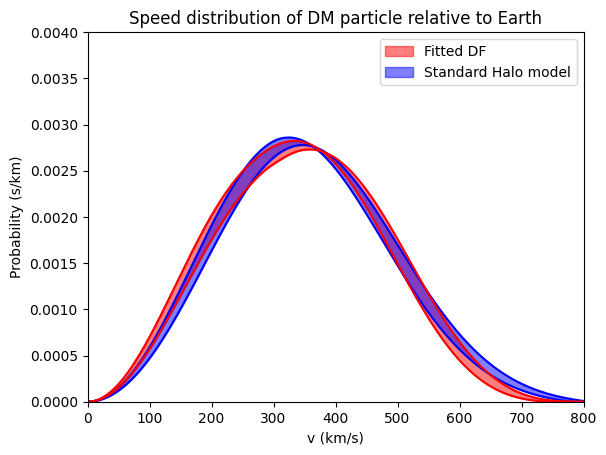

In [4]:
#Standard halo model
halo_modelS=wp.StandardHaloModel()
v=np.linspace(0.1,800,300)
times=np.linspace(0,365.25,10)
vel1=wp.v_earth(t=160)*nu.s/nu.km
vel2=wp.v_earth(t=340)*nu.s/nu.km
#160,340
A1=halo_modelnew.velocity_dist(v*nu.km/nu.s,160)*nu.km/nu.s
A2=halo_modelnew.velocity_dist(v*nu.km/nu.s,340)*nu.km/nu.s
plt.fill_between(v,A1,A2,label="Fitted DF",alpha=0.5,color="red")
y1=halo_modelS.velocity_dist(v*nu.km/nu.s,160)*nu.km/nu.s
y2=halo_modelS.velocity_dist(v*nu.km/nu.s,340)*nu.km/nu.s
#The filled area shows the approximate variation over the year of the speed distribution relative to Earth.
plt.fill_between(v,y1,y2,label="Standard Halo model",alpha=0.5,color="blue")
plt.plot(v,y1,color="blue")
plt.plot(v,y2,color="blue")
plt.plot(v,A1,color="red")
plt.plot(v,A2,color="red")
plt.legend()
plt.xlabel("v (km/s)")
plt.xlim(0,800)
plt.ylabel("Probability (s/km)")
plt.ylim(0,0.004)
plt.title("Speed distribution of DM particle relative to Earth")
plt.show()